In [1]:
# Copyright (c) TorchGeo Contributors. All rights reserved.
# Licensed under the MIT License.

## Change Detection with TorchGeo Tutorial
_Written by: Harald Kristen_

In this tutorial, we demonstrate how to train a change detection model using TorchGeo. 

**What is Change Detection**: 
Change detection is the process of identifying differences between images of the same location captured at different times. It's a fundamental task in remote sensing with numerous real-world applications:

- **Urban Monitoring**: Track city growth, new construction, and infrastructure development
- **Disaster Response**: Assess damage from floods, earthquakes, wildfires, and hurricanes
- **Deforestation Tracking**: Monitor illegal logging and forest loss
- **Agriculture**: Detect crop changes, irrigation patterns, and land use shifts
- **Environmental Monitoring**: Track glacial retreat, coastal erosion, and wetland changes

In this tutorial, we'll train a binary change detection model on the [OSCD100](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#oscd100) dataset to detect urban changes in bi-temporal Sentinel-2 imagery. Our model will learn to identify where new buildings have been constructed or existing ones removed.

It's recommended to run this notebook on Google Colab if you don't have your own GPU. Click the "Open in Colab" button above to get started.

## Setup

First, we install TorchGeo and TensorBoard.

In [2]:
%pip install torchgeo tensorboard gdown

Note: you may need to restart the kernel to use updated packages.


## Imports

Next, we import TorchGeo and any other libraries we need.

In [3]:
%matplotlib inline
%load_ext tensorboard

import os
import tempfile

import matplotlib.pyplot as plt
import torch
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger

from torchgeo.datamodules import OSCD100DataModule
from torchgeo.datasets import OSCD100
from torchgeo.trainers import ChangeDetectionTask

# Enable Tensor Cores for faster training
torch.set_float32_matmul_precision('medium')

## Visualize the Dataset

Let's download the dataset and look at some examples from OSCD100.

**About OSCD100**: This is a smaller version of the full [OSCD](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#oscd) (Onera Satellite Change Detection) dataset designed for tutorials and quick experimentation. It contains 100 image pairs at 256×256 resolution with 60 training, 20 validation, and 20 test samples.

Each sample contains all 13 Sentinel-2 spectral bands, though we visualize using RGB for display purposes. For research and benchmarking, use the full OSCD dataset.

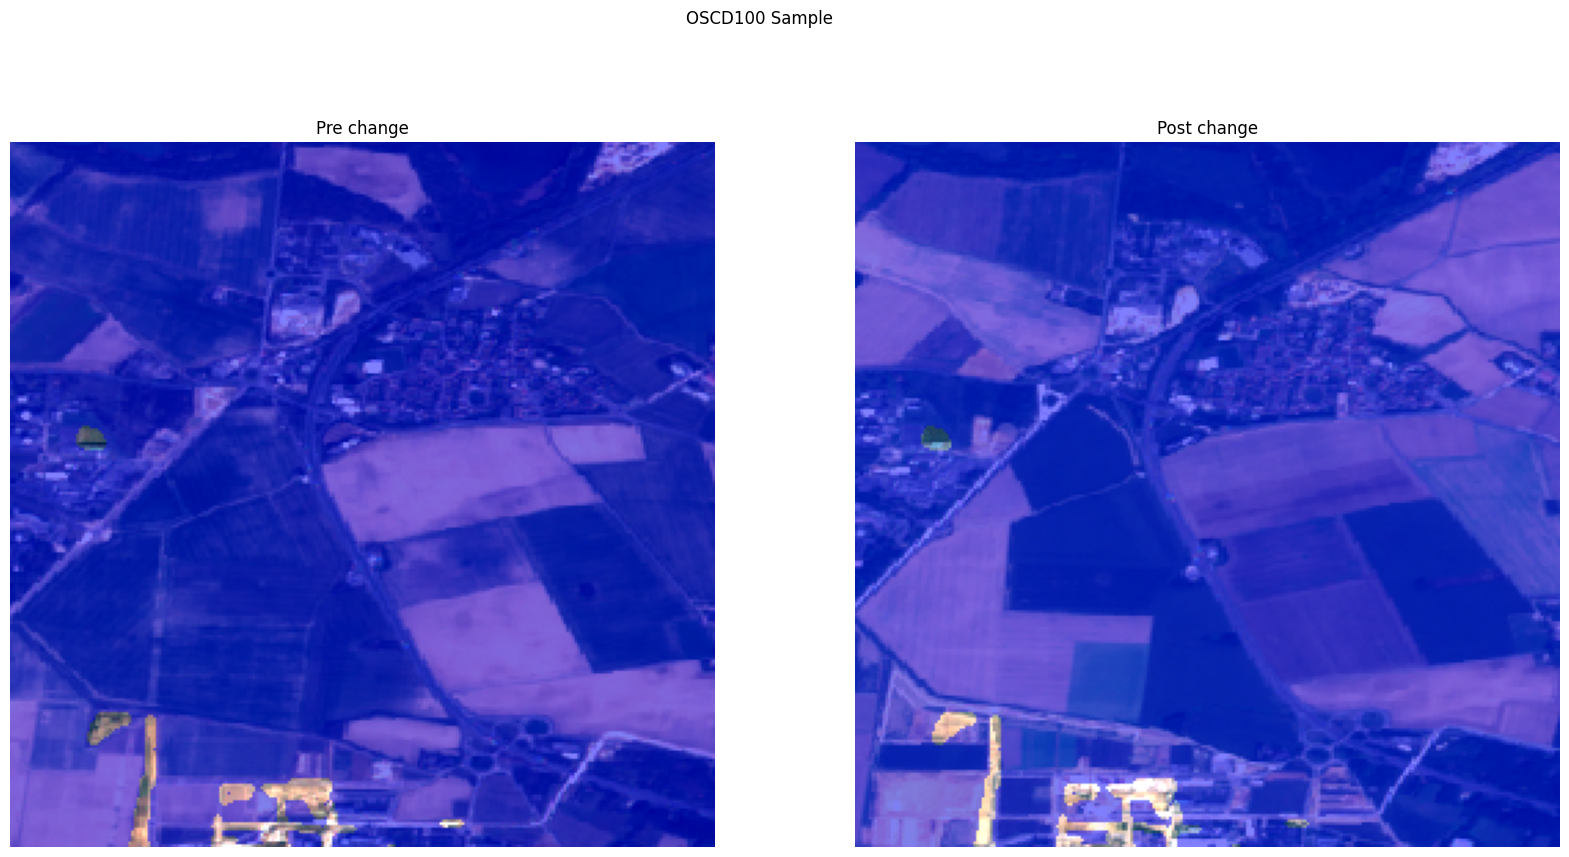

Dataset size: 60 image pairs in the train split
Image shape: torch.Size([2, 13, 256, 256]) (T, C, H, W) where T=2 timesteps, C=13 bands
Mask shape: torch.Size([1, 256, 256])


In [4]:
# Load dataset with all 13 Sentinel-2 bands
root = os.path.join(tempfile.gettempdir(), 'oscd100')
dataset = OSCD100(root=root, split='train', download=True)

# Get a sample
sample = dataset[0]

# Plot (uses RGB bands internally for visualization)
fig = dataset.plot(sample, suptitle='OSCD100 Sample')
plt.show()

print(f'Dataset size: {len(dataset)} image pairs in the {dataset.split} split')
print(
    f'Image shape: {sample["image"].shape} (T, C, H, W) where T=2 timesteps, C=13 bands'
)
print(f'Mask shape: {sample["mask"].shape}')

## Lightning Modules

We use [Lightning](https://lightning.ai/docs/pytorch/stable/) to organize the training code and dataloader setup. The `OSCD100DataModule`:
1. Downloads the data
2. Sets up train, validation, and test dataloaders
3. Applies preprocessing and augmentation

The following variables can be modified to control training.

In [5]:
batch_size = 8
num_workers = 4
max_epochs = 50
fast_dev_run = False

In [6]:
root = os.path.join(tempfile.gettempdir(), 'oscd100')
datamodule = OSCD100DataModule(
    root=root,
    bands=OSCD100.rgb_bands,  # RGB: B04 (Red), B03 (Green), B02 (Blue)
    batch_size=batch_size,
    num_workers=num_workers,
    download=True,
)

We use the `ChangeDetectionTask` class from `torchgeo.trainers`, which handles:
- Preprocessing and forwarding the bi-temporal image pair through the model
- Training with binary cross-entropy loss
- Computing metrics like accuracy, F1-score, and Jaccard Index


We use **BTC** (Bitemporal Change Transformer), a change-detection-specific architecture that uses a Swin Transformer backbone pretrained on Cityscapes followed by a UPerNet decoder. Unlike general segmentation models that simply concatenate both images into a single tensor, BTC processes them through separate encoder paths and fuses temporal features in a change-aware way.

Key configuration choices:
- **RGB bands** (`in_channels=3`): Red, Green, Blue — widely available from any optical satellite
- **`weights=True`**: Load Cityscapes-pretrained Swin-Tiny encoder
- **`lr=0.0001`**: Lower learning rate gives ~3× better F1 than the default 0.001
- **`loss='bce'`**: Binary cross-entropy, the most stable loss for this task

For other supported models and backbones, check the [trainers documentation](https://torchgeo.readthedocs.io/en/stable/api/trainers.html#torchgeo.trainers.ChangeDetectionTask).

In [7]:
task = ChangeDetectionTask(
    model='btc',
    backbone='swin_tiny',
    weights=True,  # Cityscapes-pretrained Swin-Tiny encoder
    loss='bce',
    in_channels=3,  # RGB bands
    lr=0.0001,
)

## Training

Now we can train the model using Lightning's [Trainer](https://lightning.ai/docs/pytorch/stable/common/trainer.html), that allows us to easily do:

- Model checkpointing, that saves the best model based on a metric we define
- Early stopping to prevent overfitting
- TensorBoard logs metrics for visualization

In [8]:
default_root_dir = os.path.join(tempfile.gettempdir(), 'experiments')
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss', dirpath=default_root_dir, save_top_k=1, save_last=True
)
early_stopping_callback = EarlyStopping(monitor='val_loss', min_delta=0.0, patience=10)
logger = TensorBoardLogger(save_dir=default_root_dir, name='change_detection_logs')

In [9]:
trainer = Trainer(
    callbacks=[checkpoint_callback, early_stopping_callback],
    log_every_n_steps=1,
    logger=logger,
    min_epochs=1,
    max_epochs=max_epochs,
)

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


**Note**: Training completes in ~30 seconds on a modern GPU.

In [10]:
trainer.fit(model=task, datamodule=datamodule)

/home/hkristen/miniforge3/envs/torchgeo-dev-py313/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /tmp/experiments exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



  | Name          | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | model         | BTC               | 58.9 M | train | 0    
1 | criterion     | BCEWithLogitsLoss | 0      | train | 0    
2 | train_metrics | MetricCollection  | 0      | train | 0    
3 | val_metrics   | MetricCollection  | 0      | train | 0    
4 | test_metrics  | MetricCollection  | 0      | train | 0    
--------------------------------------------------------------------
58.9 M    Trainable params
0         Non-trainable params
58.9 M    Total params
235.767   Total estimated model params size (MB)
270       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## Visualize Training with TensorBoard

Use TensorBoard to visualize metrics across epochs.

**In Google Colab**, run the cell below to launch TensorBoard inline.

**Locally**, run from your terminal `tensorboard --logdir /tmp/experiments` and navigate to http://localhost:6006

In [11]:
%tensorboard --logdir "$default_root_dir"

## Evaluation

Now we evaluate the model on the test set.

### Understanding the Metrics

- **Accuracy**: Percentage of correctly classified pixels
- **F1 Score**: Harmonic mean of precision and recall
- **Jaccard Index (IoU)**: Intersection over Union between prediction and ground truth

In [12]:
trainer.test(model=task, datamodule=datamodule, ckpt_path='best')

Restoring states from the checkpoint path at /tmp/experiments/epoch=14-step=105.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loaded model weights from the checkpoint at /tmp/experiments/epoch=14-step=105.ckpt


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_BinaryAccuracy       0.964038074016571
   test_BinaryF1Score       0.4325886070728302
 test_BinaryJaccardIndex    0.2759891748428345
        test_loss           0.12844958901405334
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.12844958901405334,
  'test_BinaryAccuracy': 0.964038074016571,
  'test_BinaryJaccardIndex': 0.2759891748428345,
  'test_BinaryF1Score': 0.4325886070728302}]

## Visualize Predictions

Let's visualize predictions on the test set using our best model.

Restoring states from the checkpoint path at /tmp/experiments/epoch=14-step=105.ckpt


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loaded model weights from the checkpoint at /tmp/experiments/epoch=14-step=105.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

Sample 0: Prediction range [0.0151, 0.1633], Change pixels: 0/4096 (0.0%)
Sample 1: Prediction range [0.0207, 0.2540], Change pixels: 0/4096 (0.0%)
Sample 2: Prediction range [0.0050, 0.0786], Change pixels: 0/4096 (0.0%)


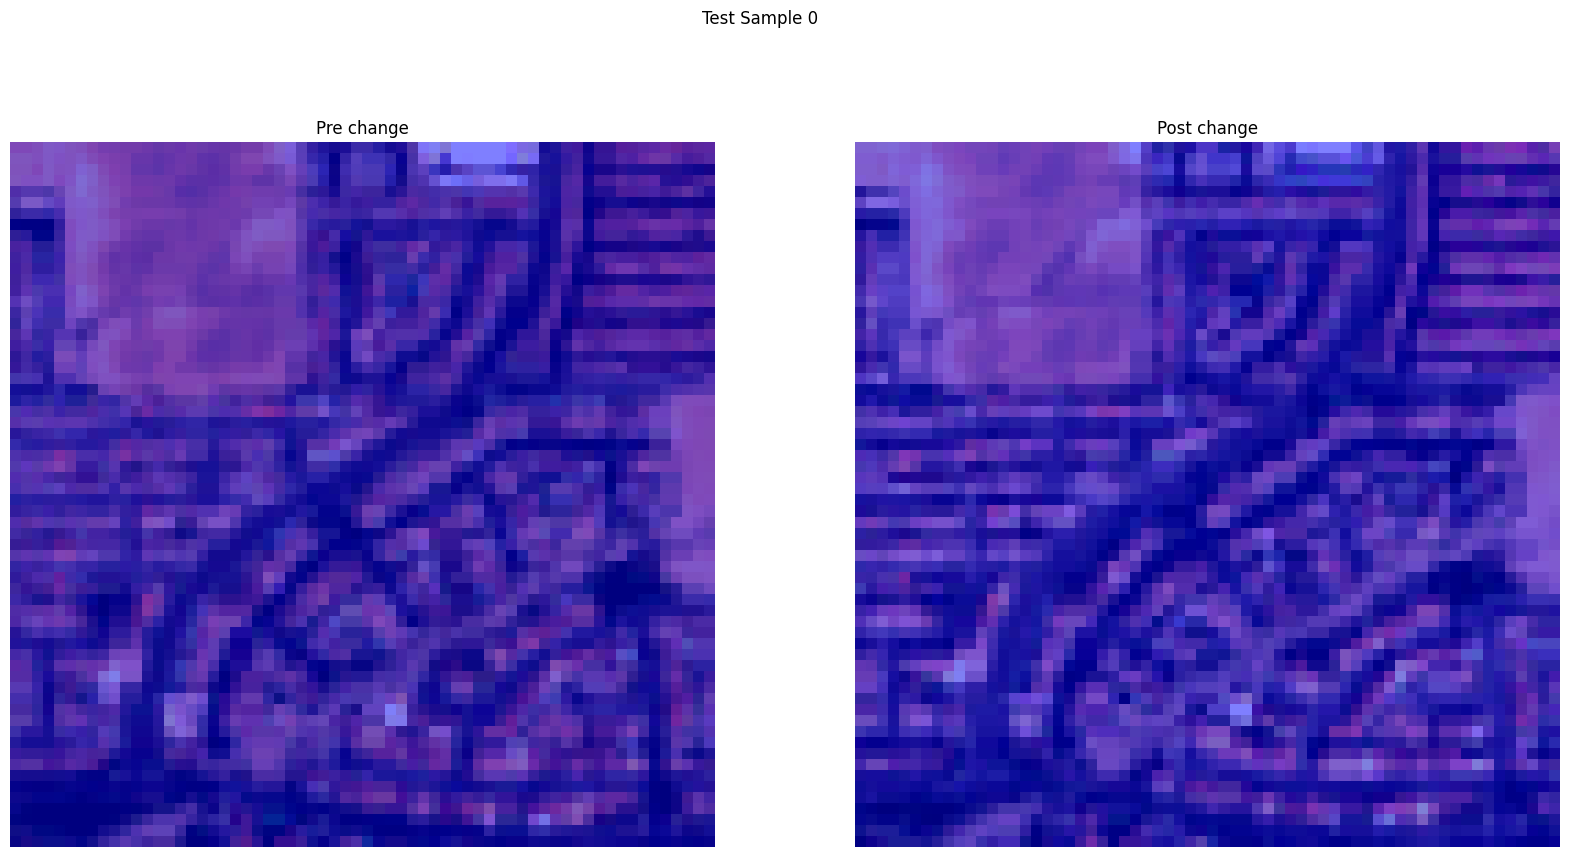

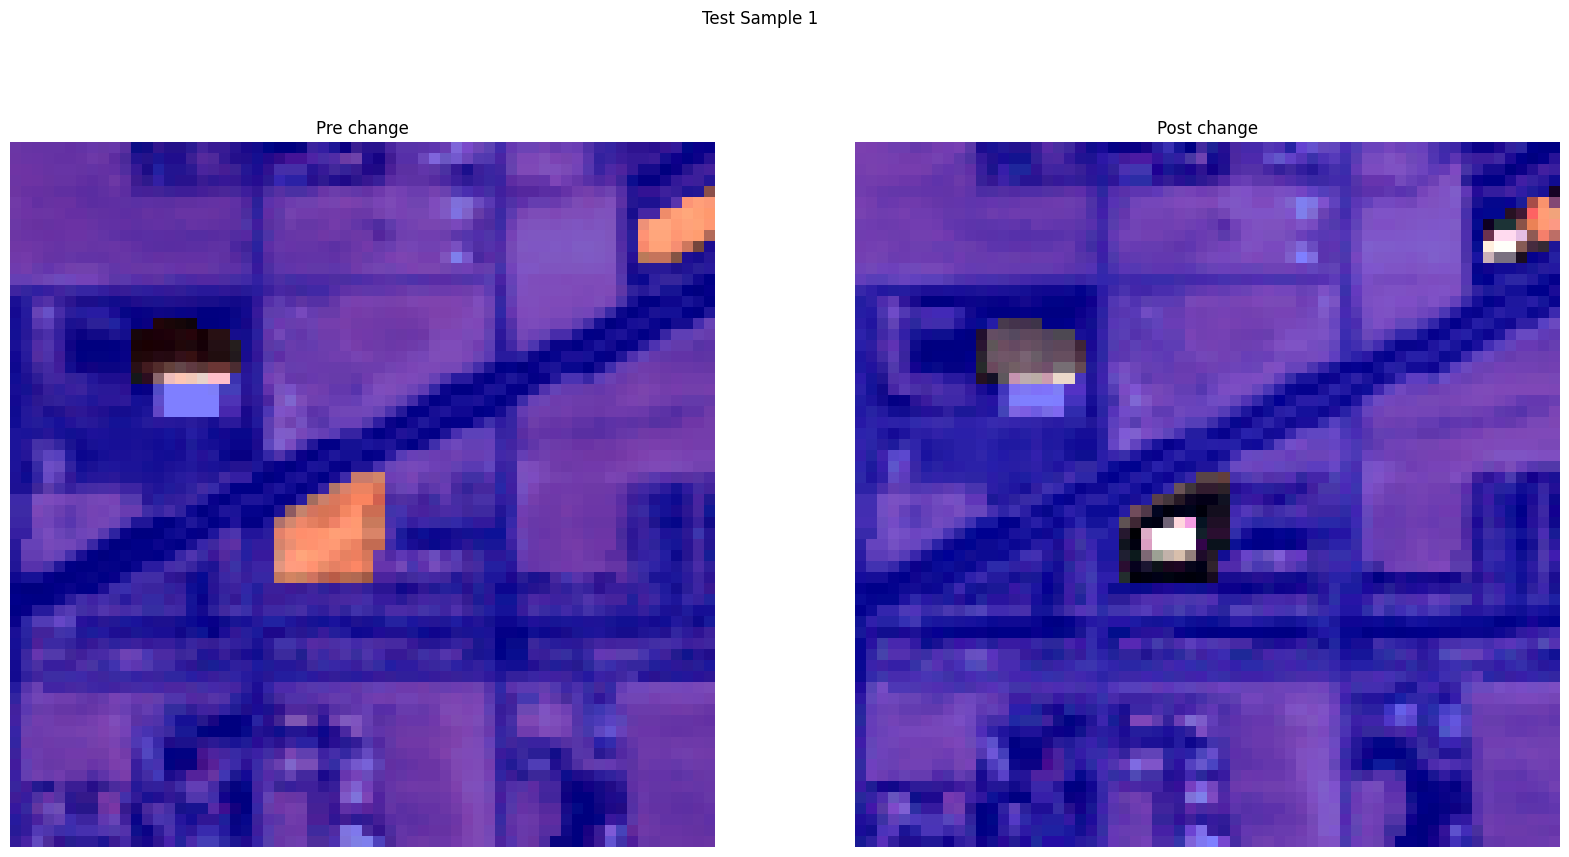

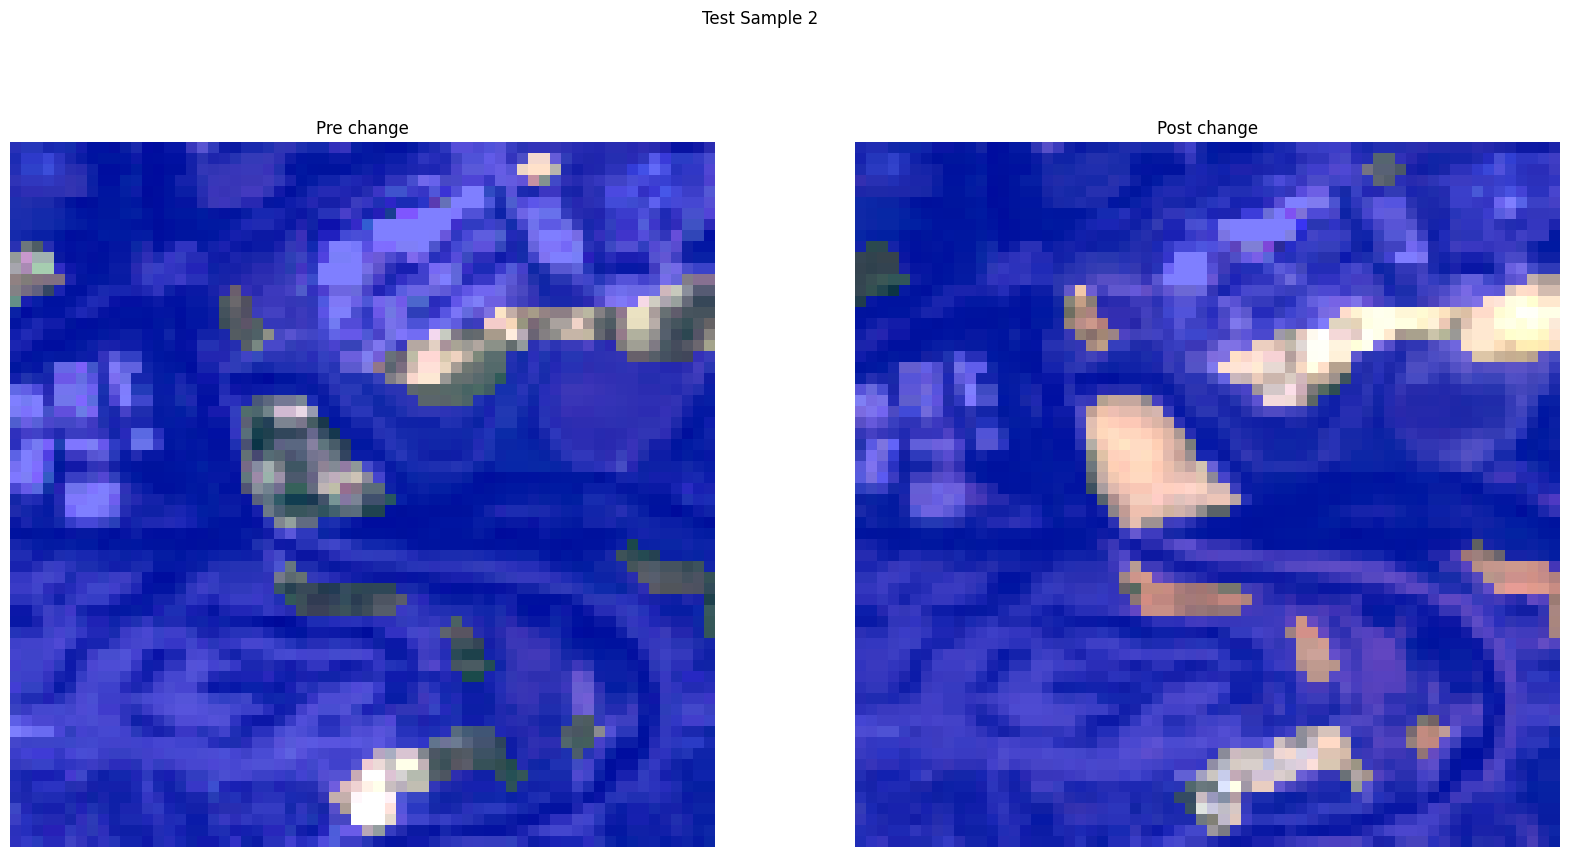

In [13]:
test_loader = datamodule.test_dataloader()
predictions = trainer.predict(task, dataloaders=test_loader, ckpt_path='best')

# Flatten predictions from batches to individual samples
all_preds = torch.cat(predictions, dim=0)

# Visualize first 3 samples
for idx in range(3):
    sample = datamodule.test_dataset[idx]

    pred_probs = all_preds[idx].cpu().squeeze()
    pred_mask = (pred_probs > 0.5).float()

    print(
        f'Sample {idx}: Prediction range [{pred_probs.min():.4f}, {pred_probs.max():.4f}], '
        f'Change pixels: {pred_mask.sum().item():.0f}/{pred_mask.numel()} '
        f'({100 * pred_mask.sum().item() / pred_mask.numel():.1f}%)'
    )

    sample['prediction'] = pred_mask.unsqueeze(0)
    fig = datamodule.test_dataset.plot(sample, suptitle=f'Test Sample {idx}')

plt.show()

### Interpreting the Results

With BTC (swin_tiny) you should expect:

- **Accuracy**: ~95–97% — high percentage of correctly classified pixels
- **F1 Score**: ~0.40–0.55 — varies with random seed and patch sampling
- **IoU (Jaccard Index)**: ~0.25–0.38

Change detection is challenging due to severe class imbalance (most pixels show no change), so an F1 above 0.35 indicates the model is successfully learning to detect changes.

**Note**: Results vary between runs due to random patch sampling and the small dataset size (60 training samples).

### To Go Further

- Train on the full [OSCD](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#oscd) dataset (24 city pairs)
- Add all 13 Sentinel-2 bands (`in_channels=3` → `in_channels=13`, set `weights=False`)
- Train for 100+ epochs with a learning rate scheduler
- Try a larger backbone (`swin_small`, `swin_base`) for higher capacity